In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1. Загружаем стандартизированный датасет из 1-й лабы
df = pd.read_csv('dataset_standardized.csv')

# 2. Оставляем непрерывные аудио-признаки
# Выкидываем текст, популярность и все One-Hot колонки (жанры, тональность, explicit), зачем нам открывать америку
cols_to_keep =[
    'duration_ms', 'tempo', 'loudness', 'danceability', 'energy', 
    'speechiness', 'acousticness', 'instrumentalness', 'liveness', 
    'valence', 'time_signature'
]
X_full = df[cols_to_keep]

# 3. делаем сэмплик
# Берем 3000 случайных треков
np.random.seed(42)
sample_indices = np.random.choice(X_full.shape[0], size=3000, replace=False)

# Наш финальный набор данных для всей 4-й лабы
X = X_full.iloc[sample_indices].reset_index(drop=True)

print("Данные для 4-й лабы готовы!")
print(f"Размер выборки: {X.shape} (3000 треков, {X.shape[1]} чистых аудио-признаков)")

Данные для 4-й лабы готовы!
Размер выборки: (3000, 11) (3000 треков, 11 чистых аудио-признаков)


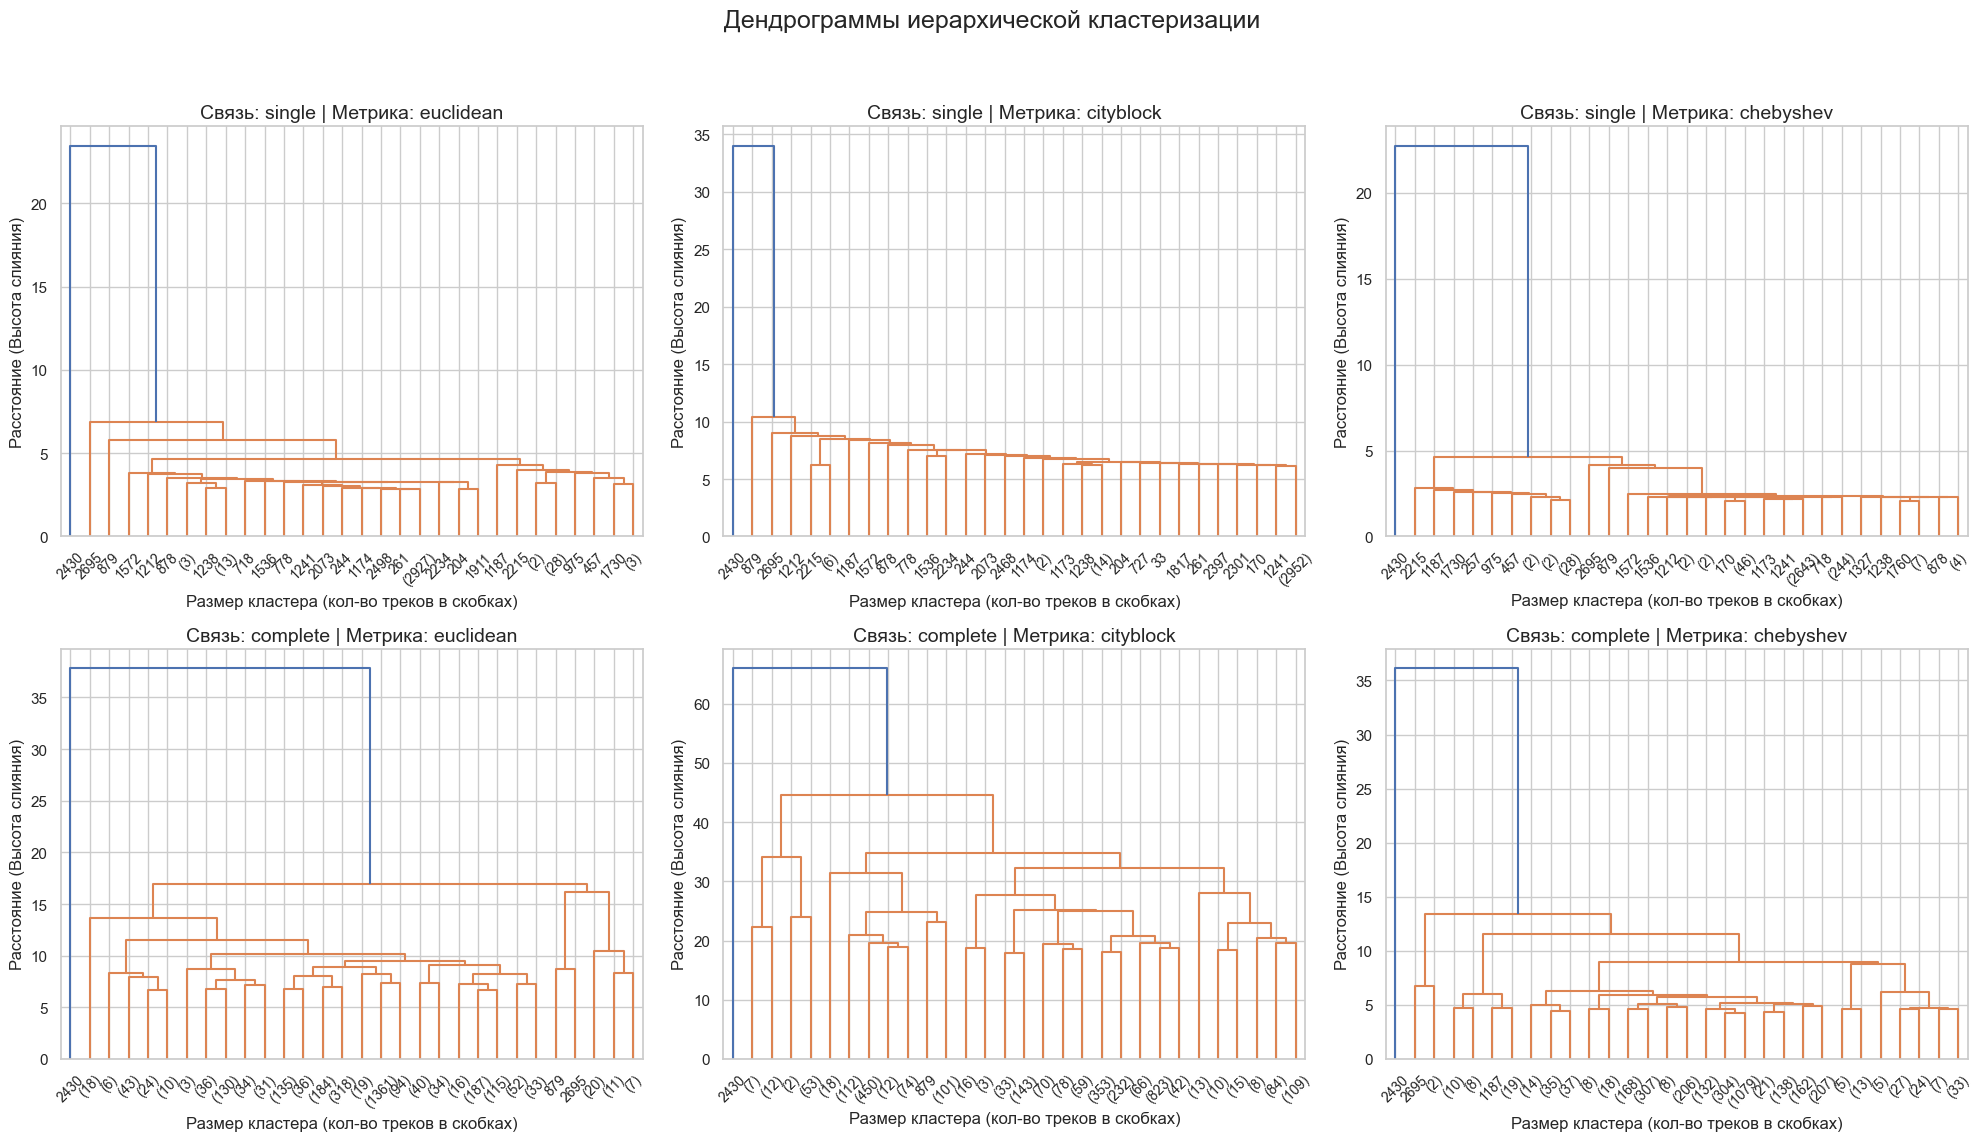

In [4]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Этап 1: Иерархическая кластеризация (Дендрограммы)

# Задаем списки методов и метрик по заданию
methods =['single', 'complete']
metrics = ['euclidean', 'cityblock', 'chebyshev']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Дендрограммы иерархической кластеризации', fontsize=18)

# Словарь для сохранения матриц связей (пригодятся для разбиения на кластеры)
linkage_matrices = {}

for i, method in enumerate(methods):
    for j, metric in enumerate(metrics):
        # Вычисляем матрицу связей (Z)
        # Алгоритм строит дерево, попарно соединяя все 3000 точек
        Z = linkage(X, method=method, metric=metric)
        
        # Сохраняем в словарь 
        dict_key = f"{method}_{metric}"
        linkage_matrices[dict_key] = Z
        
        # 2. Строим дендрограмму
        ax = axes[i, j]
        # truncate_mode='lastp', p=30 чтобы рисовал не все 3000 веток,
        # а только 30 самых верхних больших слияний.
        dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, show_leaf_counts=True)
        
        ax.set_title(f'Связь: {method} | Метрика: {metric}', fontsize=14)
        ax.set_xlabel('Размер кластера (кол-во треков в скобках)')
        ax.set_ylabel('Расстояние (Высота слияния)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

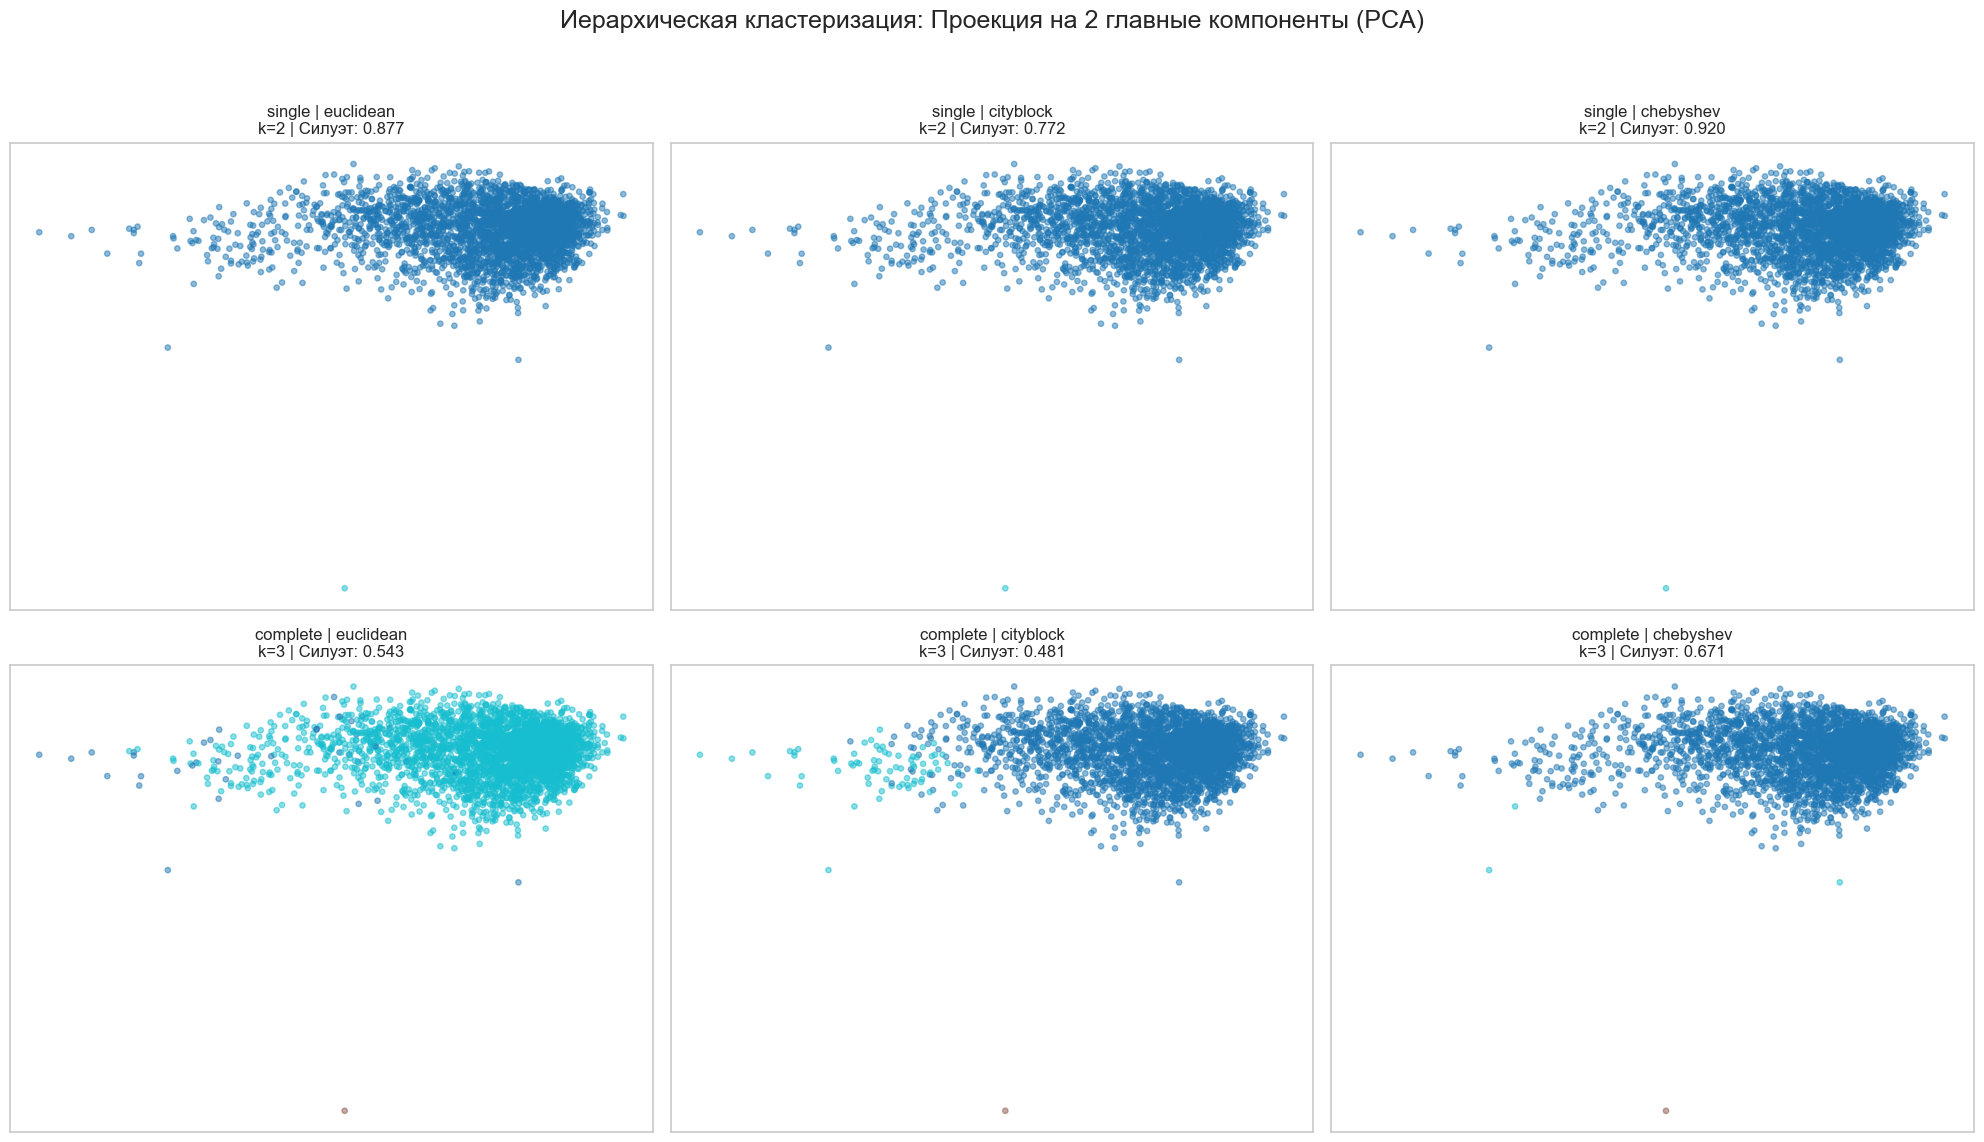

Результаты Иерархической кластеризации:


,Алгоритм,Метод связи,Метрика,Кол-во кластеров (k),Силуэт
0,Agglomerative (Иерархическая),single,euclidean,2,0.876638
1,Agglomerative (Иерархическая),single,cityblock,2,0.771917
2,Agglomerative (Иерархическая),single,chebyshev,2,0.920061
3,Agglomerative (Иерархическая),complete,euclidean,3,0.543158
4,Agglomerative (Иерархическая),complete,cityblock,3,0.480579
5,Agglomerative (Иерархическая),complete,chebyshev,3,0.670693


In [23]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Этап 1, часть 2: Разбиение, PCA визуализация и расчет Силуэта

# определили оптимальные k 
# Для single  2 
# Для complete берем 3 
# Для товарища чебышева 4 отлично смотрится
optimal_k = {
    'single_euclidean': 2,
    'single_cityblock': 2,
    'single_chebyshev': 2,
    'complete_euclidean': 3,
    'complete_cityblock': 3,
    'complete_chebyshev': 3
}

# Подготовим PCA, чтобы сжать 11 колонок в 2 координаты для рисования картинок
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Иерархическая кластеризация: Проекция на 2 главные компоненты (PCA)', fontsize=18)

# Сюда будем сохранять результаты Силуэты
results_hierarchical =[]

for i, method in enumerate(methods):
    for j, metric in enumerate(metrics):
        dict_key = f"{method}_{metric}"
        k = optimal_k[dict_key]
        
        # Запускаем кластеризацию
        cluster_model = AgglomerativeClustering(n_clusters=k, linkage=method, metric=metric)
        # Получаем метки для каждого трека
        cluster_labels = cluster_model.fit_predict(X)
        
        # Считаем коэффициент Силуэта
        silhouette = silhouette_score(X, cluster_labels, metric=metric)
        results_hierarchical.append({
            'Алгоритм': 'Agglomerative (Иерархическая)',
            'Метод связи': method,
            'Метрика': metric,
            'Кол-во кластеров (k)': k,
            'Силуэт': silhouette
        })
        
        ax = axes[i, j]
        scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=cluster_labels, cmap='tab10', alpha=0.5, s=15)
        ax.set_title(f'{method} | {metric}\nk={k} | Силуэт: {silhouette:.3f}')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

results_df = pd.DataFrame(results_hierarchical)
print("Результаты Иерархической кластеризации:")
display(results_df)

### Выводы по Этапу 1 Иерархическая кластеризация

1. Оценка метода одиночной связи: Данный метод показывает эффект цепочки. Во всех метриках он поместил единичные точки в отдельные кластеры, оставляя основную массу данных в одном гигантском кластере. Несмотря на высокие значения коэффициента силуэта, практическая ценность стремится к нулю.
2. Оценка метода полной связи: Данный метод лучше справился с задачей, сформировав кластеры плотнее. Визуальный анализ дендрограмм помог выявить оптимальные точки отсечения k=3 для всех и k=4 для чебышева. 
3. Наилучшим осмысленным разбиением считаем метод complete с метрикой chebyshev при k=4. Коэффициент силуэта 0.629, однако визуальный анализ показывает что это лучшее разделение

Считаем K-Means для разного количества кластеров от 2 до 10


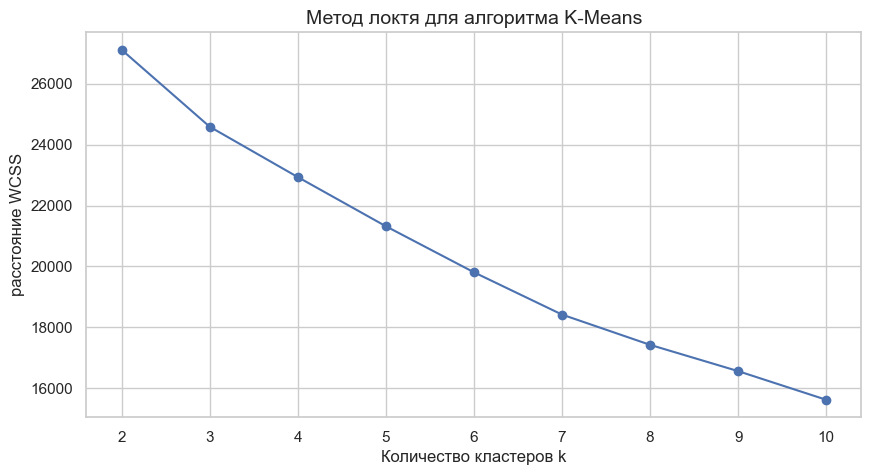


Запускаем K-Means для k=2...
Силуэт: 0.249

Запускаем K-Means для k=3...
Силуэт: 0.143


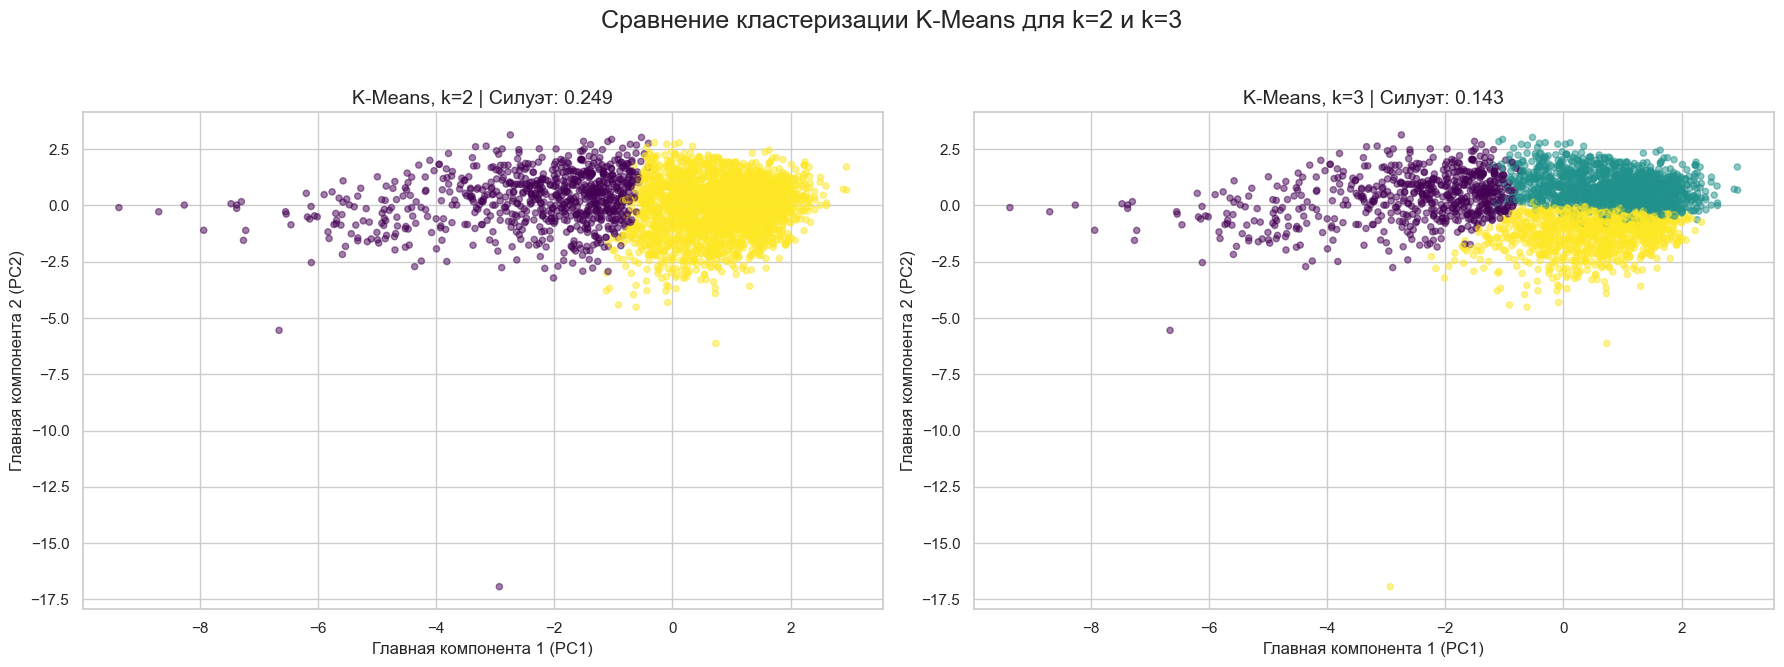

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Этап 2, часть 1: Метод локтя 
print("Считаем K-Means для разного количества кластеров от 2 до 10")

wcss =[]
K_range = range(2, 11)

for k in K_range:
    # init='k-means++' умная инициализация центров по заданию
    # n_init=10 запустится 10 раз с разными начальными точками и выберет лучший
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_) # inertia_ это WCSS


plt.figure(figsize=(10, 5))
plt.plot(K_range, wcss, marker='o', linestyle='-', color='b')
plt.title('Метод локтя для алгоритма K-Means', fontsize=14)
plt.xlabel('Количество кластеров k')
plt.ylabel('расстояние WCSS')
plt.xticks(K_range)
plt.grid(True)
plt.show()


# Этап 2, часть 2: Финальная кластеризация K-Means

# по методу локтя ничего не понятно, сравним 2 и 3
k_values_to_compare = [2, 3]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Сравнение кластеризации K-Means для k=2 и k=3', fontsize=18)

results_kmeans =[]

for i, k in enumerate(k_values_to_compare):
    print(f"\nЗапускаем K-Means для k={k}...")
    
    # Обучаем модель
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    # Считаем Силуэт
    silhouette = silhouette_score(X, labels, metric='euclidean')
    print(f"Силуэт: {silhouette:.3f}")
    
    results_kmeans.append({
        'Алгоритм': 'K-Means',
        'Метрика': 'euclidean',
        'Кол-во кластеров (k)': k,
        'Силуэт': silhouette
    })
    
    # рисуем
    ax = axes[i]
    scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels, cmap='viridis', alpha=0.5, s=20)
    ax.set_title(f'K-Means, k={k} | Силуэт: {silhouette:.3f}', fontsize=14)
    ax.set_xlabel('Главная компонента 1 (PC1)')
    ax.set_ylabel('Главная компонента 2 (PC2)')
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Выводы по Этапу 2 Алгоритм K-Means

1. График локтя не показал четкого сгиба, что говори об отсутствии в данных явных сферических кластеров
2. В связи с неоднозначностью метода локтя, рассмотрели два варианта разбиения:
   * При k=2 (Силуэт 0.249): Алгоритм произвел логичное разделение данных на два больших кластера, отделив хвост от основной плотной массы данных.
   * При k=3 (Силуэт 0.143): Алгоритм также отделил хвост и дополнительно разделил основную массу данных пополам. Хотя это позволяет провести более детальный анализ, есть вероятность, что это разделение совершенно истуственное, а не отражение реальной структуры.
3. Оба варианта имеют право на существование. k=2 является более грубым, но надежным разделением, а k=3  лучше согласуется с результатами иерархической кластеризации. Значения коэффициента силуэта в обоих случаях низкие, что ставит под сомнение применимость K-Means к нашим данным

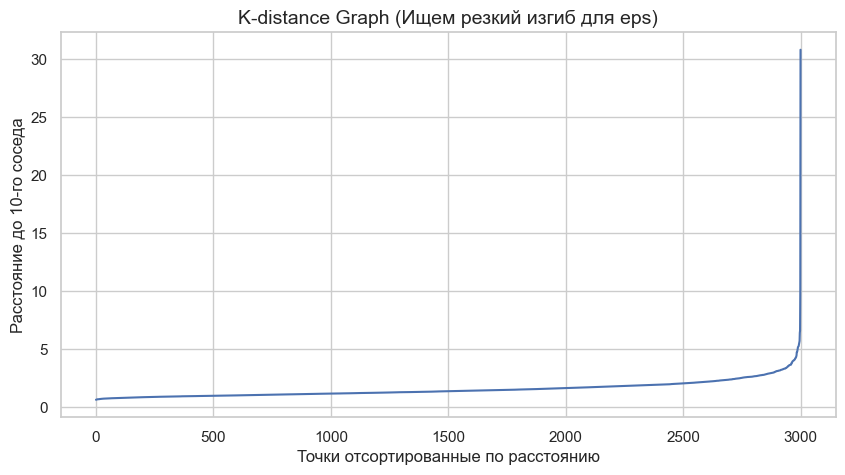

--- Результаты DBSCAN ---
1. Евклидова: Кластеров = 3, Шум = 19 точек, Силуэт = 0.497
2. Манхэттен: Кластеров = 1, Шум = 74 точек, Силуэт = 0.000


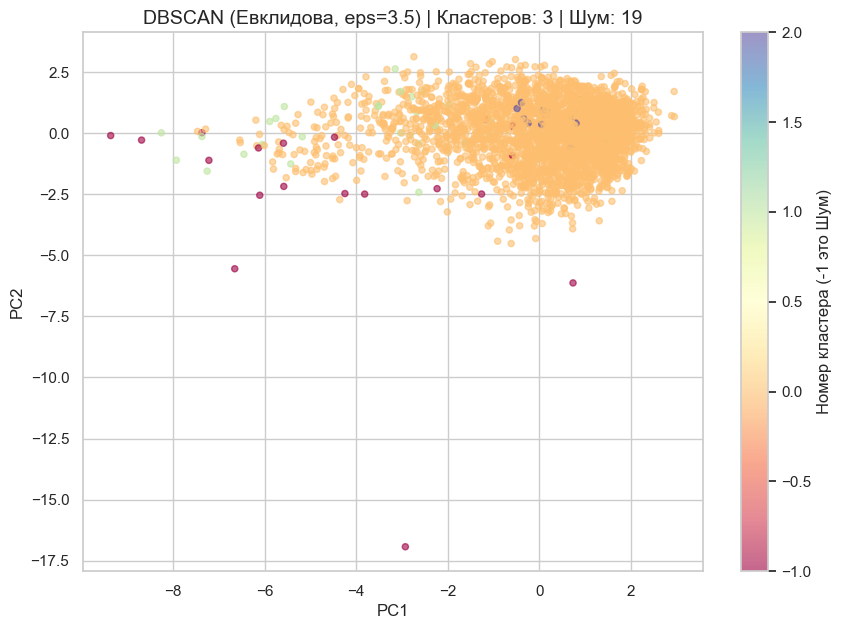

In [22]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# Этап 3, Часть 1: Поиск радиуса eps для DBSCAN

# Ищем расстояние до 10-го ближайшего соседа для каждой точки
min_pts = 10
neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Сортируем расстояния и берем только последний столбец -- расстояние до 10го соседа
distances = np.sort(distances[:, min_pts-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-distance Graph (Ищем резкий изгиб для eps)', fontsize=14)
plt.xlabel('Точки отсортированные по расстоянию')
plt.ylabel(f'Расстояние до {min_pts}-го соседа')
plt.grid(True)
plt.show()

# Этап 3, Часть 2: Кластеризация DBSCAN 

# Можем поэкспериментировать. Возьмем eps=1.0 для Евклидовой и eps=3.0 для Манхэттенской (там цифры больше)
eps_euclidean = 3.5
eps_manhattan = 6

# 1. DBSCAN с Евклидовой метрикой
dbscan_euclid = DBSCAN(eps=eps_euclidean, min_samples=min_pts, metric='euclidean')
labels_euclid = dbscan_euclid.fit_predict(X)

# 2. DBSCAN с Манхэттенской метрикой (cityblock)
dbscan_manhat = DBSCAN(eps=eps_manhattan, min_samples=min_pts, metric='cityblock')
labels_manhat = dbscan_manhat.fit_predict(X)

# Функция для подсчета силуэта без учета шума (метки -1)
def get_silhouette_dbscan(X, labels, metric):
    # Оставляем только те точки, которые не являются шумом (-1)
    mask = labels != -1
    if len(set(labels[mask])) > 1: # Если нашлось хотя бы 2 кластера
        return silhouette_score(X[mask], labels[mask], metric=metric)
    else:
        return 0.0 # Если всё слилось в 1 кластер или всё шум

sil_db_euclid = get_silhouette_dbscan(X, labels_euclid, 'euclidean')
sil_db_manhat = get_silhouette_dbscan(X, labels_manhat, 'cityblock')

# Считаем количество кластеров и шума
n_clusters_euclid = len(set(labels_euclid)) - (1 if -1 in labels_euclid else 0)
n_noise_euclid = list(labels_euclid).count(-1)

n_clusters_manhat = len(set(labels_manhat)) - (1 if -1 in labels_manhat else 0)
n_noise_manhat = list(labels_manhat).count(-1)

print("--- Результаты DBSCAN ---")
print(f"1. Евклидова: Кластеров = {n_clusters_euclid}, Шум = {n_noise_euclid} точек, Силуэт = {sil_db_euclid:.3f}")
print(f"2. Манхэттен: Кластеров = {n_clusters_manhat}, Шум = {n_noise_manhat} точек, Силуэт = {sil_db_manhat:.3f}")

# --- Визуализация Евклидова DBSCAN ---
plt.figure(figsize=(10, 7))
# Шум рисуем серым, кластеры цветными
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_euclid, cmap='Spectral', alpha=0.6, s=20)
plt.title(f'DBSCAN (Евклидова, eps={eps_euclidean}) | Кластеров: {n_clusters_euclid} | Шум: {n_noise_euclid}', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Номер кластера (-1 это Шум)')
plt.show()

### 4. Сравнение результатов и общие выводы

#### Сводная таблица результатов кластеризации

| Алгоритм | Метрика расстояния | Кол-во кластеров | Значение Силуэта | Визуальная оценка структуры |
| :--- | :--- | :--- | :--- | :--- |
| **Иерархическая (Single)** | Euclidean / Chebyshev | 2 | 0.877 / 0.920 | **Плохая.** Эффект "цепочки". Отделяет 1 точку-выброс, всё остальное сливает в мега-кластер. Высокий силуэт математически фиктивен. |
| **Иерархическая (Complete)**| **Chebyshev** | **4** | **0.629** | **Отличная.** Визуально логичное разделение плотного облака на 4 соразмерных сегмента. Лучший осмысленный результат. |
| **K-Means** | Euclidean | 3 | 0.143 | **Средняя.** Искусственно разрезает непрерывное облако на сферические доли. Низкий силуэт подтверждает отсутствие четких границ. |
| **DBSCAN** | Euclidean (eps=3.5) | 3 (и 1 группа шума) | 0.497 | **Специфичная.** Находит 1 гигантский кластер (всё облако) и 2 крошечные группы. Хорошо отсеивает шум, но не делит основную массу. |
| **DBSCAN** | Cityblock (eps=6.0) | 1 (и 1 группа шума) | 0.000 | **Плохая.** Не может найти разделения, сливает все точки в единый кластер. |

---

#### Ответы на контрольные вопросы:

**1. Какая метрика расстояния дала наилучший результат для каждого алгоритма?**
*   Для **Иерархической кластеризации** наилучший результат (баланс логичности и высокого силуэта) дала метрика **Чебышева (Chebyshev)** в комбинации с методом полной связи (`complete`).
*   Для **K-Means** классически использовалась **Евклидова (Euclidean)** метрика, так как алгоритм математически минимизирует дисперсию (сумму квадратов евклидовых расстояний).
*   Для **DBSCAN** **Евклидова** метрика показала себя лучше, сумев выделить хотя бы локальные микро-кластеры и дать силуэт ~0.497, тогда как Манхэттенская (Cityblock) слила всё в один массив.

**2. Для какого типа данных подходит каждый из методов? (Аргументация по графикам)**
*   **K-Means:** Идеально подходит для данных, где кластеры имеют **сферическую (круглую) форму, примерно одинаковый размер и одинаковую плотность**. На наших данных (непрерывное вытянутое облако) он работал плохо, так как пытался искусственно нарезать это облако на круглые "дольки" (что видно на графике PCA, где границы кластеров идут прямыми линиями).
*   **Иерархическая кластеризация:** Подходит для данных с **иерархической структурой** (когда кластеры состоят из подкластеров). Метод `complete` хорошо ищет компактные сгустки. На наших данных этот метод (с k=4) справился лучше всего, так как не был жестко привязан к поиску "круглых" центров, а смотрел на максимальные дистанции между группами.
*   **DBSCAN:** Идеален для поиска кластеров **абсолютно любой сложной формы** (змейки, кольца) и данных с большим количеством **аномалий/шума**. Однако он категорически **не подходит для данных с разной плотностью или сплошных непрерывных облаков** (как наши аудио-данные). На графиках мы четко видели этот недостаток: DBSCAN просто "растекся" по всему облаку, объединив 95% треков в один кластер, так как между ними не было пустых "проливов" пониженной плотности.

In [25]:
#TODO надо пересмотреть выводы
в иерархии чебышев странно разделил, как будто манхэттен лучше, осмысленнее на три поделил
для k_means добавить вывод по 2 кластерам
для дбскан переделать код чтобы выводил несколько вариантов от 2.5, 5 до 3.5)
сделать цвета более различимыми


SyntaxError: unmatched ')' (1736825346.py, line 4)